# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on stock data.

In [1]:
%pip install python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
# Add project root to path so `src` is importable from the notebook
sys.path.append('..')

from src.utils.config import DEFAULT_TICKERS, RAW_DATA_DIR

%matplotlib inline
sns.set_style('darkgrid')

## Load Data

In [8]:
# Load stock data
# Use a ticker from the project's configured list (DEFAULT_TICKERS)
from pathlib import Path
ticker = DEFAULT_TICKERS[1]  # TCS.NS (use index 0..4 to pick other tickers)
data_path = RAW_DATA_DIR / f"{ticker}.csv"
print('Using ticker:', ticker)
data = pd.read_csv(data_path, index_col=0, parse_dates=True)
data.head()

Using ticker: TCS.NS


C:\Users\Nihar\AppData\Local\Temp\ipykernel_3736\1433500913.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(data_path, index_col=0, parse_dates=True)


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,NaN,NaN,NaN,NaN,NaN
2020-01-01,1900.03759765625,1914.325399993125,1888.1162580573948,1900.388137171974,1354908
2020-01-02,1891.315673828125,1910.8630674205476,1883.9087608358507,1910.8630674205476,2380752
2020-01-03,1929.0081787109375,1948.599446330552,1896.882232055472,1896.882232055472,4655761


## Basic Statistics

In [9]:
data.describe()

,Close,High,Low,Open,Volume
count,1226,1226,1226,1226,1226
unique,1220,1226,1226,1226,1226
top,3411.093505859375,4299.10768027082,4258.857847404851,4282.872604248985,1635256
freq,2,1,1,1,1


## Price Trends

In [10]:
# Data checks before plotting
print('data type:', type(data))
print('columns:', list(data.columns))
print('index dtype:', data.index.dtype)
print(data.head())
# Ensure 'Close' exists and is numeric
if 'Close' in data.columns:
    data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
    print("'Close' dtype after coercion:", data['Close'].dtype)
    print("'Close' NaNs:", data['Close'].isna().sum())
else:
    print("Column 'Close' not found in data. Available columns:", list(data.columns))
# Ensure 'Volume' exists and is numeric
if 'Volume' in data.columns:
    data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')
    print("'Volume' dtype after coercion:", data['Volume'].dtype)
    print("'Volume' NaNs:", data['Volume'].isna().sum())
else:
    print("Column 'Volume' not found in data. Available columns:", list(data.columns))
# Convert index to datetime if needed
if not np.issubdtype(data.index.dtype, np.datetime64):
    try:
        data.index = pd.to_datetime(data.index)
        print('Converted index to datetime')
    except Exception as e:
        print('Failed to convert index to datetime:', e)
# Drop rows where Close or Volume are NaN to avoid plotting errors
before_rows = len(data)
data = data.dropna(subset=['Close','Volume'])
after_rows = len(data)
print(f'Dropped {before_rows - after_rows} rows with NaN Close/Volume')

data type: <class 'pandas.core.frame.DataFrame'>
columns: ['Close', 'High', 'Low', 'Open', 'Volume']
index dtype: object
                         Close                High                 Low  \
Price                                                                    
Ticker                  TCS.NS              TCS.NS              TCS.NS   
Date                       NaN                 NaN                 NaN   
2020-01-01    1900.03759765625   1914.325399993125  1888.1162580573948   
2020-01-02   1891.315673828125  1910.8630674205476  1883.9087608358507   
2020-01-03  1929.0081787109375   1948.599446330552   1896.882232055472   

                          Open   Volume  
Price                                    
Ticker                  TCS.NS   TCS.NS  
Date                       NaN      NaN  
2020-01-01   1900.388137171974  1354908  
2020-01-02  1910.8630674205476  2380752  
2020-01-03   1896.882232055472  4655761  
'Close' dtype after coercion: float64
'Close' NaNs: 2
'Volume' dty

C:\Users\Nihar\AppData\Local\Temp\ipykernel_3736\2236103919.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.index = pd.to_datetime(data.index)


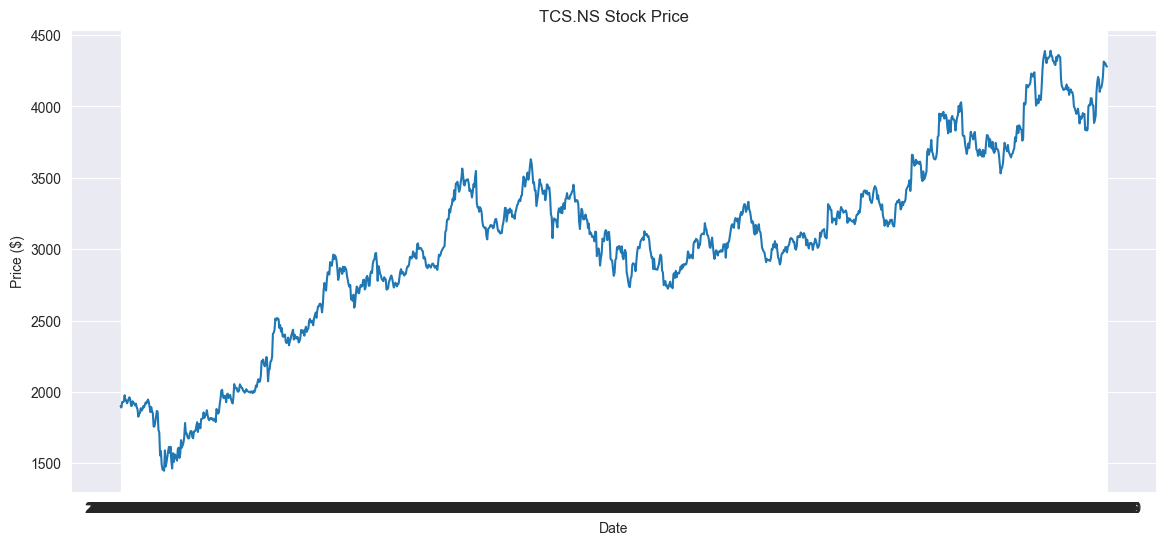

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['Close'])
plt.title(f'{ticker} Stock Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()

## Volume Analysis

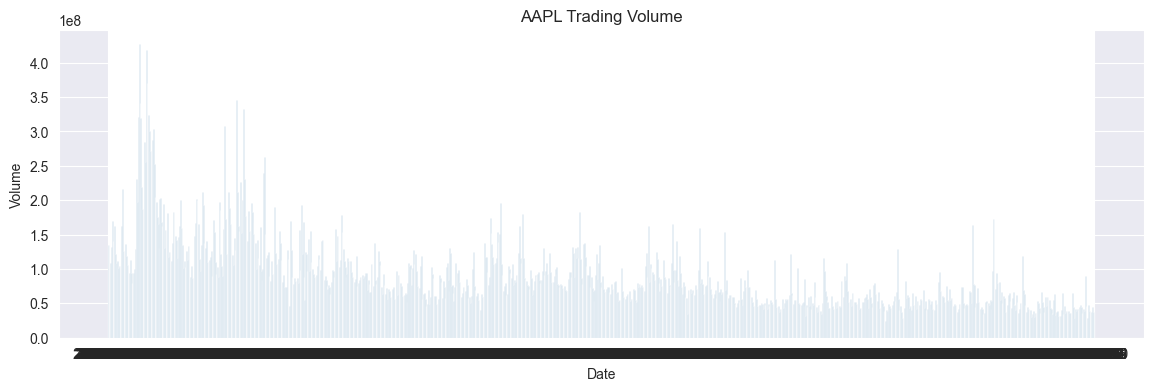

In [14]:
plt.figure(figsize=(14, 4))
plt.bar(data.index, data['Volume'], color='steelblue', alpha=0.5)
plt.title(f'{ticker} Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

## Returns Distribution

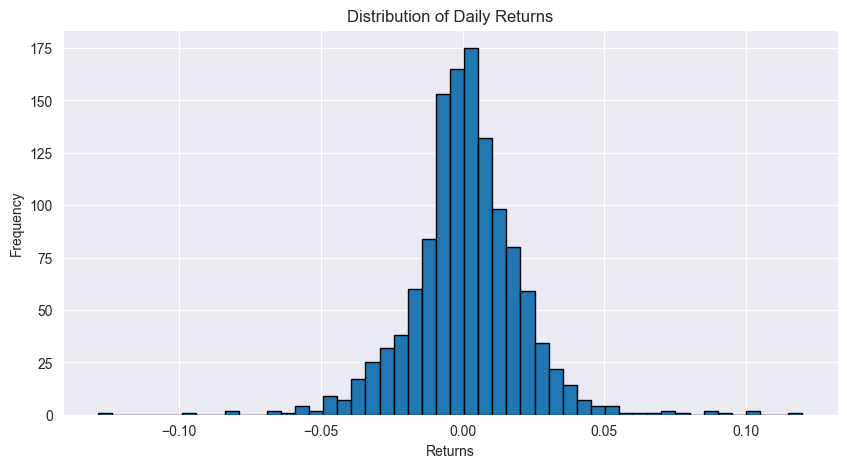

In [15]:
data['returns'] = data['Close'].pct_change()

plt.figure(figsize=(10, 5))
plt.hist(data['returns'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Daily Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()